In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [4]:
b5= bd.iloc[85]

In [5]:
b5['datetime']

'2020-07-12,10:40:48.322654+00:00'

In [6]:
lat= literal_eval(b5['lat_stereo_g17'])
long= literal_eval(b5['lat_stereo_g17'])
alt= literal_eval(b5['alt_stereo_g17'])
energy = literal_eval(b5['energyJoules_stereo_g17'])

In [7]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])*0.0175
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [8]:
print (len(lat), len(long), len(alt), len(energy))

73 73 73 73


In [9]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

62


In [10]:
totalmass= 0
totalh= 0 
for i in range (62): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [11]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.00011413430818571394 5.326267715333317e-05 0.0005326267715333317


In [12]:
totalh

12842.02369711279

In [13]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

0.0010723399999932326
0.0015916600000025483
5.1859999999237516e-05
-0.0004846500000041942
-0.0010212600000016891
-0.0010081100000007837
-0.0007572699999940369
-0.001280649999998218
-0.0002591500000050928
-0.0002635299999980134
-0.00026359000000297783
-0.000522949999989919
0.001756099999994376
0.002015009999993822
0.001504590000010353
0.001751099999992789
0.001236239999997224
0.00047967999999798394
0.001496850000009431
5.161645780000001
3.09299999941004e-05
-0.00020843000000070333
-0.00020845000000235814
-0.0002084399999944253
0.0002768800000012561
0.0004969700000003741
0.0002288299999975152
0.0005008400000008351
0.0004887300000007144
8.249999993381607e-06
7.780000004231624e-06
3.399999997100167e-06
0.00026754000001005807
3.4099999908221434e-06
-0.0005159399999996594
-0.0007595000000009122
-0.0010274999999921874
-0.0007512600000012526
-0.0007593400000018846
-0.0002473100000059958
0.0004997600000109514
0.0004790599999893175
0.0004751700000014125
0.00021915000000660712
-0.0002812400000067

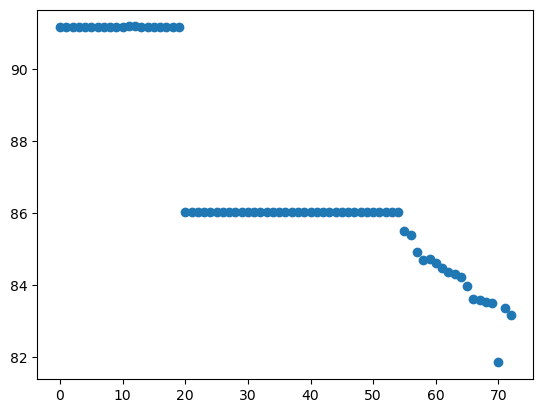

In [14]:
plt.scatter(range(len(alt)), alt)